In [4]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
#os.chdir(r"E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")

print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


## 1. Identification of events

In [ ]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final station criteria
yr_strt=1980;yr_end=2020
period=22; miss_prc=4
gauge_final=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_final.set_index('GaugeID',inplace=True)



# Threshold criteria
th=98.5
ICT=10 #days
tau=7

# Variable initialization
ssn=['All','Monsoon','Post-monsoon']
ssn_months=[[1,2,3,4,5,6,7,8,9,10,11,12],[6,7,8,9],[10,11,12]]


dates=pd.date_range(start='1950',end='2022',freq='D')


# Loading data
ds=xr.open_dataset("3_Data/Data_p/4_PPT IMD/PPT_station.nc")

null_stations=[]

for s,seas in tqdm(enumerate(ssn_months)):

    strm_events_matrix=pd.DataFrame(np.nan,index=dates,columns=gauge_final.index.values)
    ppt_events_matrix=pd.DataFrame(np.nan,index=dates,columns=gauge_final.index.values)

    for stn in gauge_final.index.values:

        df=ds.sel(Station=gauge_final.loc[stn,'Station']).to_dataframe()
        strm_flw=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True)
        time_clip=pd.date_range(start=strm_flw.index.min(),end=strm_flw.index.max(),freq='D')

        data=df.loc[time_clip,:]
        data_ss=data.loc[data.index.month.isin(seas),:]

        
        if (data_ss[['Ppt','Streamflow']].isna().all().sum() == 0):          # At gauge 10, ppt have full nan value
            
            strm_events = event_identification(data_ss,th,ICT,'Streamflow')      
            ppt_events  = event_identification(data_ss,th,ICT,'Ppt')
            
            strm_events_matrix.loc[strm_events['Peak Date'],stn]=1
            ppt_events_matrix.loc[ppt_events['Peak Date'],stn]=1

        else:
            null_stations.append(stn)
            strm_events_matrix.drop(columns=stn,inplace=True)
            ppt_events_matrix.drop(columns=stn,inplace=True)
            gauge_final.drop(stn,inplace=True)

    strm_events_matrix.to_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\strm_events_{ssn[s]}.csv")
    ppt_events_matrix.to_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\ppt_events_{ssn[s]}.csv")

    strm_connect=connectedness2(strm_events_matrix,tau,gauge_final)
    ppt_connect=connectedness2(ppt_events_matrix,tau,gauge_final)

    # #strm_ppt_connect

    strm_connect.to_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\strm_ES_{ssn[s]}.csv")
    ppt_connect.to_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\ppt_ES_{ssn[s]}.csv")
    gauge_final.to_csv(r"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\gauge_info.csv")

0it [00:00, ?it/s]

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_23720\518787881.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['exceedence']=(data1[var]>th_value).astype(int)
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_23720\518787881.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['change point']=data1['exceedence'].diff().fillna(0)
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_23720\518787881.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

# Plots 

### 1_Average_seasonality of events and connection diagram

In [6]:
# Creation of Euclidian Distance
Euc_matrix=pd.DataFrame(index=gauge_final.index,columns=gauge_final.index)

stn1=gauge_final.index.values[0]

for stn1 in gauge_final.index:

    station_lon=gauge_final.loc[stn1,'Longitude']
    station_lat=gauge_final.loc[stn1,'Latitude']

    gauge_final['Latitude'].to_numpy()

    distance = np.sqrt((gauge_final['Latitude'].to_numpy() - station_lat) ** 2 + (gauge_final['Longitude'].to_numpy() - station_lon) ** 2)
    Euc_matrix.loc[stn1,:]=distance

Euc_matrix

GaugeID,IWM-gauge-17,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-36,IWM-gauge-40,IWM-gauge-54,IWM-gauge-57,IWM-gauge-60,IWM-gauge-68,...,IWM-gauge-995,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1001,IWM-gauge-1004,IWM-gauge-1006,IWM-gauge-1078,IWM-gauge-1103
GaugeID,,,,,,,,,,,,,,,,,,,,,
IWM-gauge-17,0.0,0.870648,1.944332,1.55862,3.893695,1.262724,2.625573,0.195681,2.558936,3.916607,...,15.982029,15.718534,15.536523,16.159976,15.791043,15.860885,15.689052,16.012392,12.904691,16.079142
IWM-gauge-27,0.870648,0.0,1.17691,0.962181,4.243338,2.130581,2.92729,0.696645,2.78826,4.333162,...,15.604627,15.398557,15.181586,15.812315,15.445174,15.545221,15.381723,15.721266,13.285234,16.357438
IWM-gauge-29,1.944332,1.17691,0.0,0.534765,4.247087,3.179505,2.990125,1.748905,2.774876,4.426316,...,14.584017,14.425337,14.179678,14.815134,14.450162,14.575376,14.419424,14.772399,13.145354,16.055254
IWM-gauge-32,1.55862,0.962181,0.534765,0.0,3.784034,2.740818,2.501709,1.365972,2.300061,3.944255,...,14.643176,14.442683,14.221727,14.853048,14.486137,14.589938,14.427767,14.770006,12.74402,15.71078
IWM-gauge-36,3.893695,4.243338,4.247087,3.784034,0.0,3.836269,1.316692,3.877493,1.48646,0.354844,...,13.514,13.031314,12.989425,13.568285,13.201474,13.154059,12.955381,13.212336,9.044226,12.185887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-1001,15.860885,15.545221,14.575376,14.589938,13.154059,16.504383,13.771791,15.718706,13.673217,13.430451,...,1.220726,0.166771,0.833417,0.690478,0.593439,0.0,0.231881,0.502098,11.769065,10.902044
IWM-gauge-1004,15.689052,15.381723,14.419424,14.427767,12.955381,16.322409,13.584229,15.54822,13.48809,13.229773,...,1.39537,0.243202,0.930171,0.907783,0.748417,0.231881,0.0,0.45468,11.541785,10.700281
IWM-gauge-1006,16.012392,15.721266,14.772399,14.770006,13.212336,16.623274,13.872349,15.874327,13.782389,13.480194,...,1.700789,0.635809,1.332761,1.11811,1.092275,0.502098,0.45468,0.0,11.477382,10.49773


In [23]:
var=['strm','ppt']
var_names=['Flood extremes','Precipitation extremes']
ssn=['All','Monsoon','Post-monsoon']
ssn_months=[[1,2,3,4,5,6,7,8,9,10,11,12],[6,7,8,9],[10,11,12]]

s=0;v=1
ES_df=pd.read_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\{var[v]}_ES_{ssn[s]}.csv",index_col=0)

gauge_final=pd.read_csv(r"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\gauge_info.csv",index_col=0)
stations=gauge_final.index.values

events_mtx=pd.read_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\{var[v]}_events_{ssn[s]}.csv",index_col=0,parse_dates=[0])

for stn in stations:
    gauge_final.loc[stn,'average day']=events_mtx[events_mtx[stn]==1].index.dayofyear.to_numpy().mean()



ES_mtx=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
for i in range(len(ES_df)):
    
    ES_mtx.loc[ES_df.loc[i,'x'],ES_df.loc[i,'y']]=ES_df.loc[i,'ES']
    ES_mtx.loc[ES_df.loc[i,'y'],ES_df.loc[i,'x']]=ES_df.loc[i,'ES']

ES_mtx_radiused=ES_mtx[Euc_matrix<5.5]

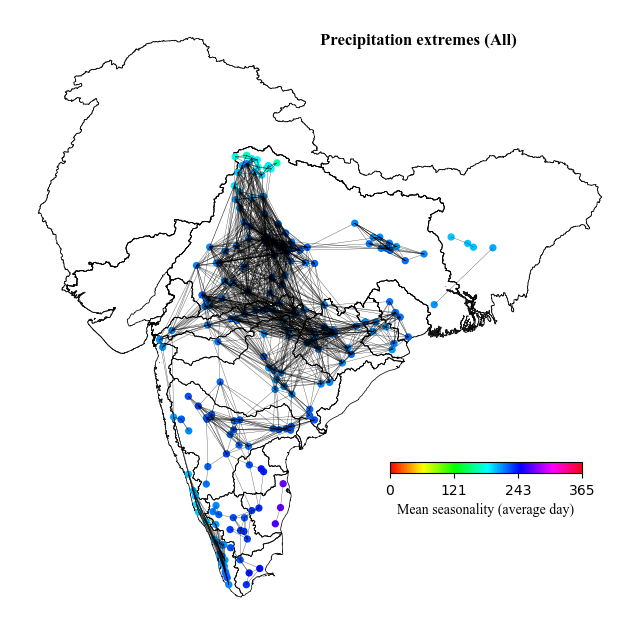

In [24]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

fig, ax1 = plt.subplots(1, 1, figsize=(8,8), subplot_kw={"projection": ccrs.PlateCarree()})
south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

#Axis setting
[x.set_visible(False) for x in ax1.spines.values()]
[x.set_linewidth(0.2) for x in ax1.spines.values()]


sc=ax1.scatter(gauge_final['Longitude'],gauge_final['Latitude'],c=gauge_final['average day'],cmap='hsv',s=18,edgecolor=None)

threshold = 0.40# Define threshold for strong synchronization
for stn1 in stations:
    for stn2 in stations:
        if stn1 != stn2 and ES_mtx_radiused.loc[stn1, stn2] > threshold:
            lon1, lat1 = gauge_final.loc[stn1,['Longitude','Latitude']]
            lon2, lat2 = gauge_final.loc[stn2,['Longitude','Latitude']]

            ax1.plot([lon1, lon2], [lat1, lat2], color='black', linewidth=0.2, alpha=0.5)



ax1.text(0.50, 0.95, f'{var_names[v]} ({ssn[s]})', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
transform=ax1.transAxes, ha='left', va='center')


cbar_ax = fig.add_axes([0.6, 0.3, 0.24, 0.014])
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='horizontal', fraction=0.03, pad=0.02)
cbar.ax.set_xlabel('Mean seasonality (average day)', fontsize=10, fontname='Times New Roman')
cbar.ax.xaxis.set_label_position('top')
cbar.set_ticks(np.linspace(0, 365, 4))  # Adjust ticks if needed
sc.set_clim(0, 365)
# Force integer formatting for tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
#cbar.ax.xaxis.set_ticks_position('top')
#plt.savefig(fr'3_Spatial connectivity\Outputs\spatial_connect.png', bbox_inches='tight',dpi=1000)
plt.savefig(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\1_Average_day\{var[v]}_{ssn[s]}", bbox_inches='tight',dpi=200)

### 2 Connectedness plot

In [6]:
# Creation of Euclidian Distance
gauge_final=pd.read_csv(r"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\gauge_info.csv",index_col=0)
stn1=gauge_final.index.values[0]

Euc_matrix=pd.DataFrame(index=gauge_final.index,columns=gauge_final.index)
for stn1 in gauge_final.index:

    station_lon=gauge_final.loc[stn1,'Longitude']
    station_lat=gauge_final.loc[stn1,'Latitude']

    gauge_final['Latitude'].to_numpy()

    distance = np.sqrt((gauge_final['Latitude'].to_numpy() - station_lat) ** 2 + (gauge_final['Longitude'].to_numpy() - station_lon) ** 2)
    Euc_matrix.loc[stn1,:]=distance


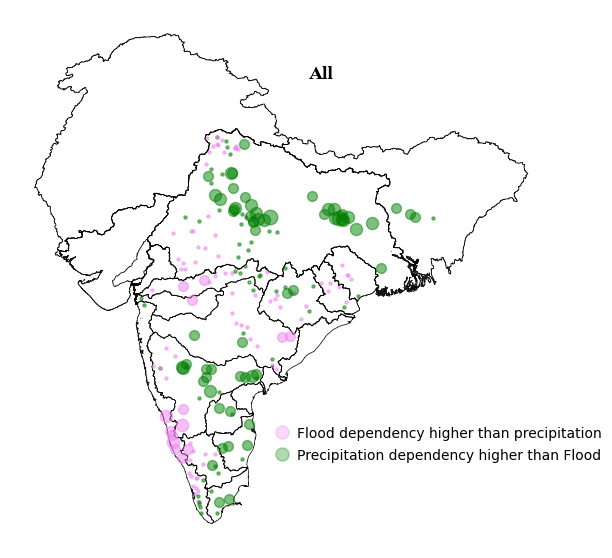

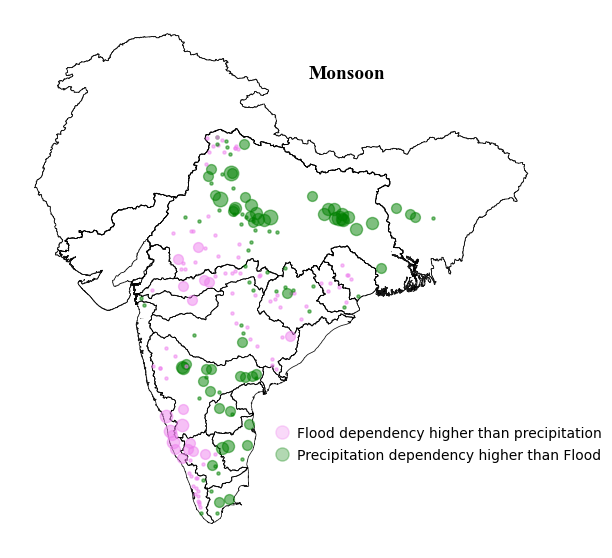

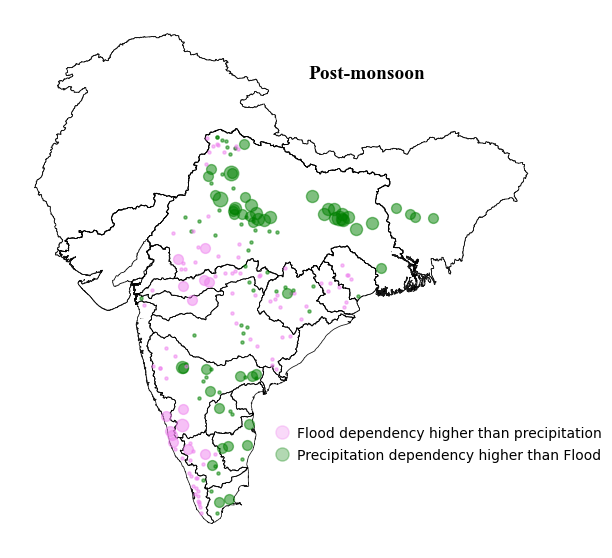

In [7]:
ssn=['All','Monsoon','Post-monsoon']
color1=['dodgerblue','red']
var=['strm','ppt']
var_names=['flood','precipitation']

for s in range(len(ssn)):
    for idx_v,v in enumerate(var):

        gauge_final=pd.read_csv(r"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\gauge_info.csv",index_col=0)
        stations=gauge_final.index.values
        ppt_df=pd.read_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\ppt_ES_{ssn[s]}.csv",index_col=0)
        strm_df=pd.read_csv(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\strm_ES_{ssn[s]}.csv",index_col=0)

        strm_mtx=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
        ppt_mtx=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)

        for i in range(len(ppt_df)):
            
            ppt_mtx.loc[ppt_df.loc[i,'x'],ppt_df.loc[i,'y']]=ppt_df.loc[i,'ES']
            ppt_mtx.loc[ppt_df.loc[i,'y'],ppt_df.loc[i,'x']]=ppt_df.loc[i,'ES']

            strm_mtx.loc[strm_df.loc[i,'x'],strm_df.loc[i,'y']]=strm_df.loc[i,'ES']
            strm_mtx.loc[strm_df.loc[i,'y'],strm_df.loc[i,'x']]=strm_df.loc[i,'ES']


        # Finding average Synchronization strength of station with others withing a radius of 3degree around the station
        gauge_final['ppt_ES']=ppt_mtx[Euc_matrix<2.5].mean(axis=1)
        gauge_final['strm_ES']=strm_mtx[Euc_matrix<2.5].mean(axis=1)
        gauge_final['ppt_strm_ES']=(ppt_mtx-strm_mtx)[Euc_matrix<2.5].mean(axis=1)


        # creating bins 
        gauge_final['ppt_ES'] = pd.cut(gauge_final['ppt_ES'], bins=[0,0.1,0.2,0.3,0.5,0.8,1.2], labels=[5,15,40,70,120,200])
        gauge_final['strm_ES'] = pd.cut(gauge_final['strm_ES'], bins=[0,0.1,0.2,0.3,0.5,0.8,1.2], labels=[5,15,40,70,120,200])
        gauge_final['ppt_strm_ES_col']=gauge_final['ppt_strm_ES'].apply(lambda x: 'green' if x>0 else 'violet')
        gauge_final['ppt_strm_ESS'] = pd.cut(gauge_final['ppt_strm_ES'], bins=[-0.5,-0.2,-0.1,0,0.1,0.2,0.3,0.5], labels=[80,50,5,5.1,50.1,75.1,110])


        self_connection_plot(gauge_final,color1[idx_v],ssn[s],v,var_names[idx_v])

    cross_connection_plot(gauge_final,ssn[s])


In [1]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker


def self_connection_plot(gauge_final,col,seas,vr,vr_n):

    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

    fig, ax1 = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]



    for i in range(len(gauge_final)):
        ax1.scatter(
            gauge_final['Longitude'][i], gauge_final['Latitude'][i],
            s=gauge_final[f'{v}_ES'][i],  # Size based on synchronization strength
            color=col, edgecolor='None', alpha=0.4
        )



    ax1.text(0.55, 0.88, f'{seas}', fontsize=14, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')



    ### LEgend
    
    legend_sizes = [20, 50, 100]  # Adjusted sizes
    legend_labels = ["Low", "Medium", "High"]  # Labels

    # X positions for circles (placed outside the map at a fixed location)
    x_pos = [86, 88, 90]  # Adjust based on your map's extent
    y_pos = 15  # Fixed Y position for alignment

    # Create legend circles
    for size, x in zip(legend_sizes, x_pos):
        ax1.scatter(x, y_pos, s=size, color=col, alpha=0.3, transform=ccrs.PlateCarree())

    # Add legend text
    ax1.text(85, 16, f"Strength of {vr_n}\nconnectedness", fontsize=10, ha="left",
            transform=ccrs.PlateCarree())

    # Hide axis for clean plot
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    #cbar.ax.xaxis.set_ticks_position('top')
    #plt.savefig(fr'3_Spatial connectivity\Outputs\spatial_connect.png', bbox_inches='tight',dpi=1000)
    plt.savefig(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\2_Connection_plot\{vr}_{seas}", bbox_inches='tight',dpi=200)
    plt.close()

   

In [2]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker


def cross_connection_plot(gauge_final,seas):

    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

    fig, ax1 = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]



    for i in range(len(gauge_final)):
        ax1.scatter(
            gauge_final['Longitude'][i], gauge_final['Latitude'][i],
            s=gauge_final['ppt_strm_ESS'][i],  # Size based on synchronization strength
            color=gauge_final['ppt_strm_ES_col'][i], edgecolor=None, alpha=0.5
        )


    ax1.text(0.55, 0.88, f'{seas}', fontsize=14, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')



    ### LEgend
    # === ADDING LEGEND ===
    legend_sizes = [20, 50, 100]  # Adjusted sizes
    legend_labels = ["Low", "Medium", "High"]  # Labels

    # X positions for circles (placed outside the map at a fixed location)
    x_pos = [86, 88, 90]  # Adjust based on your map's extent
    y_pos = 15  # Fixed Y position for alignment

    # Create legend circles
    ax1.scatter(82, 13.5, s=90, color="violet", alpha=0.3, transform=ccrs.PlateCarree())
    ax1.text(83, 13.2, "Flood dependency higher than precipitation", fontsize=10, ha="left",transform=ccrs.PlateCarree())

    ax1.scatter(82, 12.2, s=90, color="green", alpha=0.3, transform=ccrs.PlateCarree())
    ax1.text(83, 11.9, "Precipitation dependency higher than Flood", fontsize=10, ha="left",transform=ccrs.PlateCarree())

    # Hide axis for clean plot
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    #cbar.ax.xaxis.set_ticks_position('top')
    #plt.savefig(fr'3_Spatial connectivity\Outputs\spatial_connect.png', bbox_inches='tight',dpi=1000)
    plt.savefig(fr"2_Analysis\3_Spatial connectivity\1_Simple Connectedness\Outputs\2_Connection_plot\streamflow_ppt_{seas}", bbox_inches='tight',dpi=200)


# Functions

### 1. POT identification and elimination of dependent events

In [3]:
def event_identification (data1,th,ICT,var):


    th_value=np.nanpercentile(data1[var].dropna(),th)

    data1['exceedence']=(data1[var]>th_value).astype(int)
    data1['change point']=data1['exceedence'].diff().fillna(0)


    data1['flood start']=data1['change point']==1
    data1['event']=data1['flood start'].cumsum()

    floods=data1[data1['exceedence']==1]
    flood_events=floods.groupby('event')


    results = []
    for event, group in flood_events:
        start = group.index[0]
        end = group.index[-1]
        duration = (end - start).days+1
        peak = group[var].max()
        peak_date = group[var].idxmax() 
        severity = group[var].sum()
        
        results.append([start, end, duration,severity, peak,peak_date])


    flood_summary = pd.DataFrame(results, columns=['Start', 'End', 'Duration (days)','Severity', 'Peak Flow','Peak Date'])


    # Handling dependent events (Event occuring in a few days gap)
    flood_summary["Gap (days)"] = flood_summary["Start"]-flood_summary["End"].shift(1) #Calculate gap between consecutive events
    flood_summary["Gap (days)"] = flood_summary["Gap (days)"].dt.days  # Convert to integer days
    flood_summary['Gap binary'] = (flood_summary["Gap (days)"] < ICT).astype(int)
    flood_summary["Group"] = (flood_summary["Gap binary"] == 0).cumsum()
    merged_floods = flood_summary.groupby("Group").agg({
        "Start": "min",  # Earliest start date in the group
        "End": "max",  # Latest end date in the group
        "Duration (days)": "sum",  # Sum durations
        "Severity": "sum",  # Sum severities
        "Peak Flow": "max",  # Max peak flow in the group
        "Peak Date": "min"  # Earliest peak date in the group
    }).reset_index()

    merged_floods=merged_floods.iloc[0:-1,0:7]
    
    return merged_floods


### 2. Flood connectedness Method 2



In [4]:
import itertools
import pandas as pd


def connectedness2(data2,tau,gauge_final):

    combinations = list(itertools.combinations_with_replacement(gauge_final.index.values, 2))
    result_df=pd.DataFrame(combinations, columns=["x", "y"])
    result_df


    for i in tqdm(range(len(result_df))):

        #Clip the common dates
        x=result_df['x'][i]
        y=result_df['y'][i]
        clip_st=gauge_final.loc[[x,y],'Start_date'].max()
        clip_end=gauge_final.loc[[x,y],'End_date'].min()
        data2_clip=data2.loc[clip_st:clip_end]



        # 1. Y/X (X is in flood and what is the chance that Y being in flood)
        event_x=data2_clip[data2_clip[x]==1].copy()
        sum_x=event_x[x].sum()
        #result_df.loc[i,'sum_x']=event_x[x].sum()
        

        date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_x.index for i in range(0, tau)])) # Set helps to store only unique date
        datetime_index = pd.DatetimeIndex(date_window)
        yx_forward=data2.loc[datetime_index,:][y].sum()


        date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_x.index for i in range(1, tau)])) # Set helps to store only unique date
        datetime_index = pd.DatetimeIndex(date_window)
        yx_backward=data2.loc[datetime_index,:][y].sum()

        S_yx=yx_forward+yx_backward
        result_df.loc[i,'S_yx']=S_yx



        # 2. X/Y (Y is in flood and what is the chance that X being in flood)
        event_y=data2_clip[data2_clip[y]==1].copy()
        sum_y=event_y[y].sum()
        # #result_df.loc[i,'sum_y']=event_y[y].sum()

        date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_y.index for i in range(0, tau)])) # Set helps to store only unique date
        datetime_index = pd.DatetimeIndex(date_window)
        xy_forward=data2.loc[datetime_index,:][x].sum()
   

        # date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_y.index for i in range(1, tau)])) # Set helps to store only unique date
        # datetime_index = pd.DatetimeIndex(date_window)
        # xy_backward=data2.loc[datetime_index,:][x].sum()
  
        # S_xy=xy_forward+xy_backward
        # result_df.loc[i,'S_xy']=S_xy



        # 3 Total synchornization
        result_df.loc[i,'ES']=(2*S_yx)/(sum_y+sum_x)

        #4 Directionality
        result_df.loc[i,'Directionality']=(yx_forward-xy_forward)/(sum_y+sum_x)


        delay=[]
        for x_date in event_x.index:
            date_window = sorted(set([x_date + pd.Timedelta(days=i) for i in range(1 - tau, tau)]))
            
            events=data2.loc[pd.DatetimeIndex(date_window),:]
            y_date=events[events[y]==1].index
            
            if pd.notna(y_date.mean()):
                delay.append((y_date.mean() - x_date).days)  # sometime more than one event of y will come in the window, so take mean

        # Compute the average delay
        result_df.loc[i, "Delay"] = np.mean(delay)

    return result_df


### 3. flood-ppt connectedness  

In [5]:
tau=7 

data_strm=strm_matrix
data_ppt=ppt_matrix

def connectedness(data_strm,data_ppt,tau,gauge_final):
    connect_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)

    for stn in gauge_final.index:
        
        event_strm=data_strm.loc[data_strm[stn]==1,:]
        sum_strm=data_strm[stn].sum()

        date_window = sorted(set([x_date + pd.Timedelta(days=i) for x_date in event_strm.index for i in range(1 - tau, 0)]))
            
        events=data_ppt.loc[pd.DatetimeIndex(date_window),:]
        events_sum=events.sum(axis=0).values
        connect_matrix.loc[stn,:]=events_sum/(sum_strm)

    return connect_matrix


NameError: name 'strm_matrix' is not defined

In [71]:
connect_matrix

,IWM-gauge-17,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-36,IWM-gauge-40,IWM-gauge-54,IWM-gauge-57,IWM-gauge-60,IWM-gauge-68,...,IWM-gauge-995,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1001,IWM-gauge-1004,IWM-gauge-1006,IWM-gauge-1078,IWM-gauge-1103
IWM-gauge-17,0.565217,0.586957,0.347826,0.630435,0.086957,0.239130,0.391304,0.608696,0.326087,0.217391,...,0.130435,0.108696,0.086957,0.065217,0.108696,0.043478,0.108696,0.086957,0.000000,0.086957
IWM-gauge-27,0.130435,0.304348,0.217391,0.239130,0.065217,0.021739,0.108696,0.130435,0.152174,0.260870,...,0.043478,0.065217,0.065217,0.130435,0.086957,0.086957,0.065217,0.065217,0.086957,0.065217
IWM-gauge-29,0.049296,0.119718,0.147887,0.105634,0.056338,0.028169,0.105634,0.063380,0.112676,0.091549,...,0.056338,0.098592,0.070423,0.077465,0.105634,0.049296,0.042254,0.070423,0.063380,0.014085
IWM-gauge-32,0.102273,0.181818,0.215909,0.204545,0.090909,0.045455,0.181818,0.147727,0.181818,0.147727,...,0.079545,0.056818,0.102273,0.079545,0.147727,0.045455,0.022727,0.079545,0.068182,0.034091
IWM-gauge-36,0.060606,0.090909,0.333333,0.181818,0.303030,0.030303,0.212121,0.030303,0.242424,0.333333,...,0.060606,0.151515,0.151515,0.060606,0.272727,0.121212,0.151515,0.272727,0.090909,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IWM-gauge-1001,0.000000,0.057692,0.211538,0.211538,0.173077,0.038462,0.153846,0.000000,0.230769,0.230769,...,0.153846,0.250000,0.134615,0.134615,0.173077,0.269231,0.250000,0.192308,0.076923,0.000000
IWM-gauge-1004,0.053571,0.017857,0.142857,0.142857,0.178571,0.071429,0.178571,0.053571,0.196429,0.267857,...,0.178571,0.196429,0.178571,0.196429,0.178571,0.160714,0.160714,0.232143,0.071429,0.071429
IWM-gauge-1006,0.031250,0.000000,0.156250,0.031250,0.156250,0.031250,0.156250,0.000000,0.125000,0.093750,...,0.125000,0.281250,0.218750,0.187500,0.218750,0.218750,0.187500,0.250000,0.187500,0.125000
IWM-gauge-1078,0.029412,0.147059,0.088235,0.117647,0.176471,0.000000,0.029412,0.029412,0.088235,0.147059,...,0.029412,0.088235,0.088235,0.088235,0.058824,0.088235,0.117647,0.117647,0.352941,0.058824
